In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('/content/heart (4).csv')


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(302, 14)

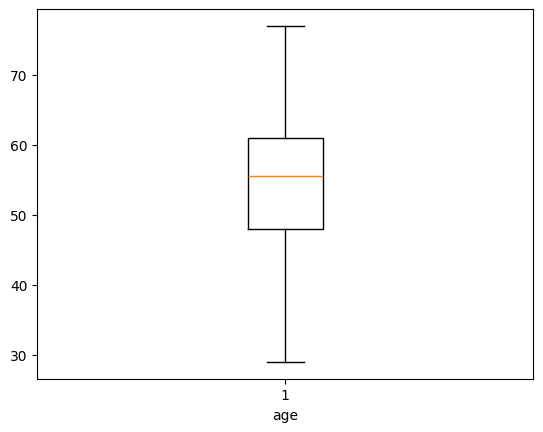

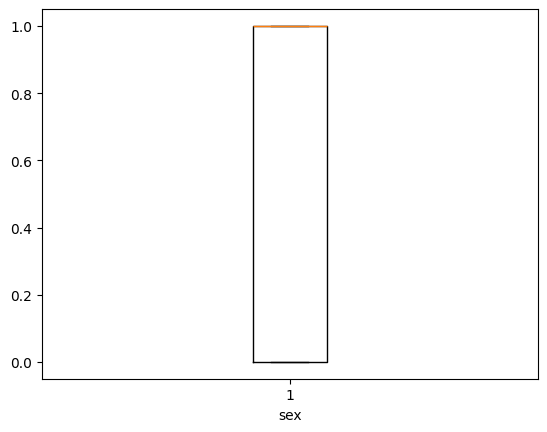

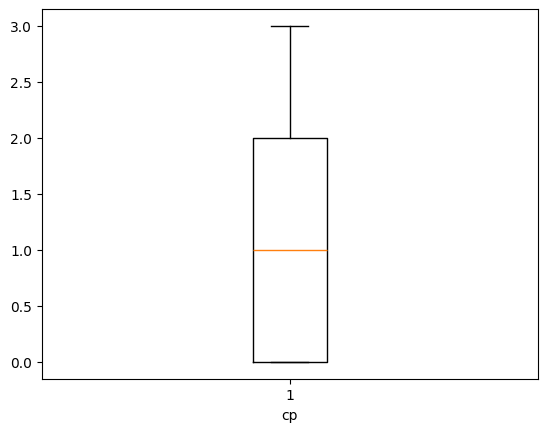

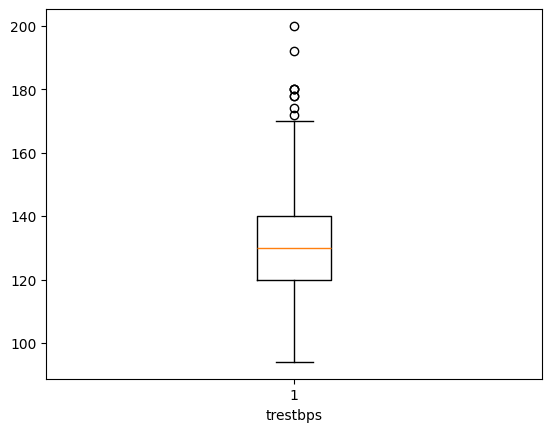

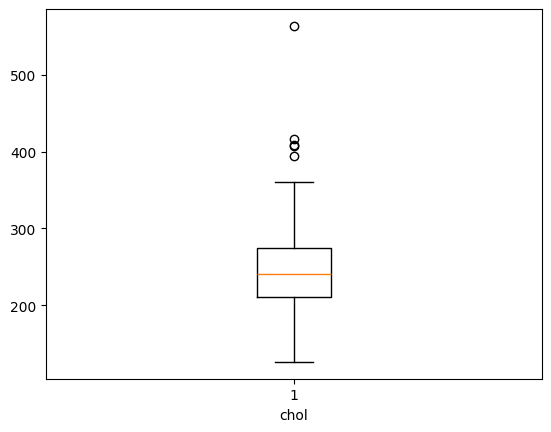

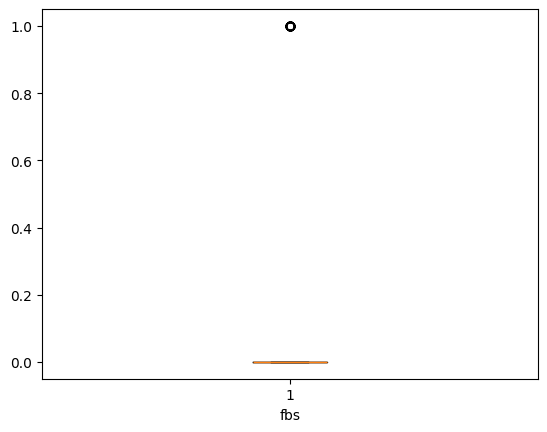

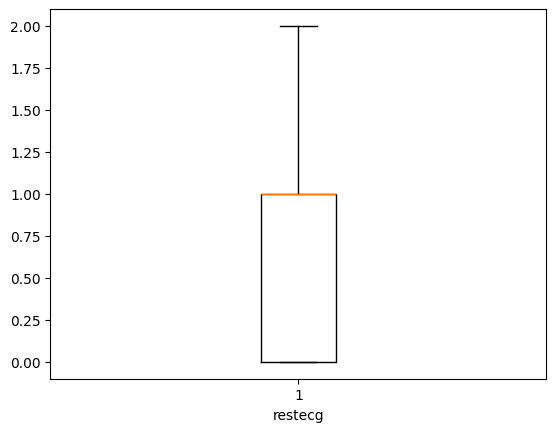

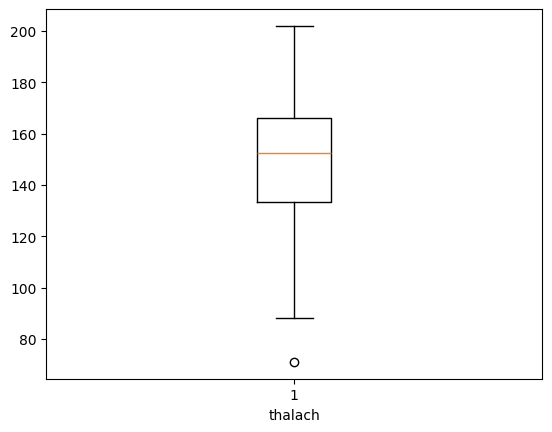

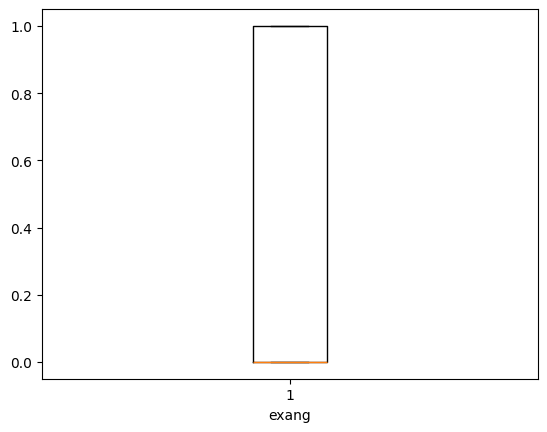

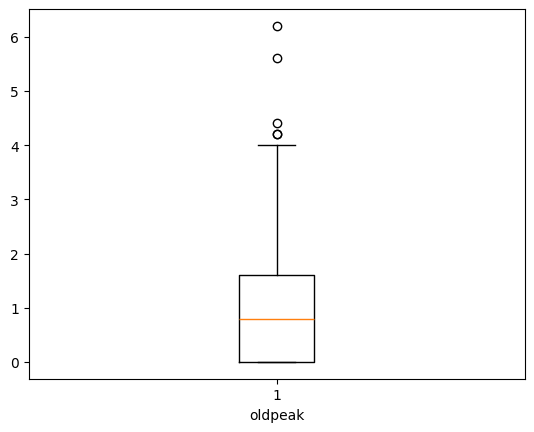

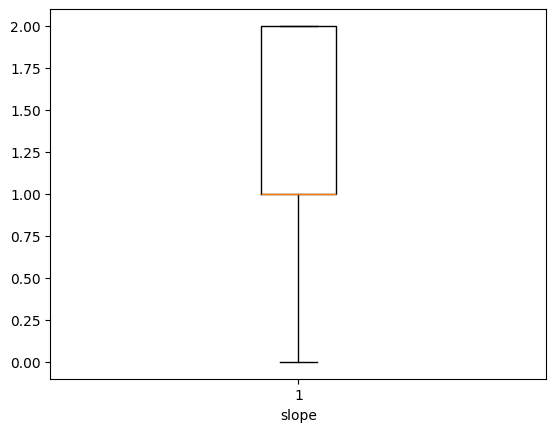

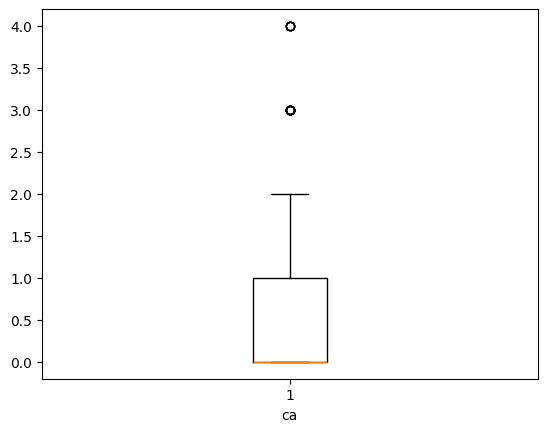

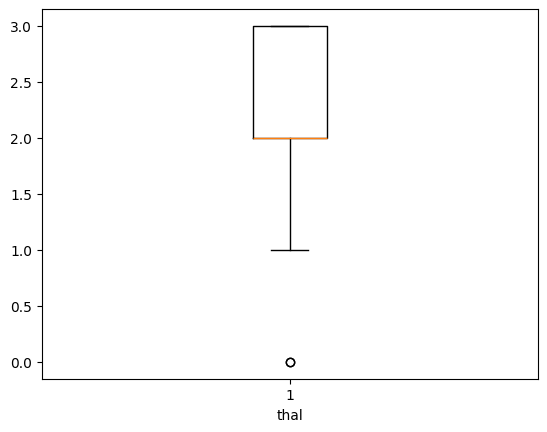

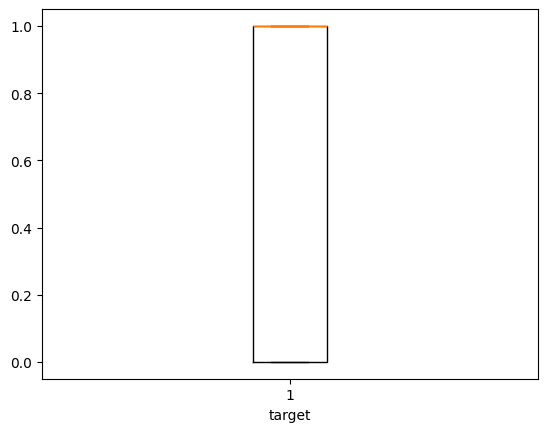

In [ ]:
#Checking for Outliers
for col in df.columns:
  if(df[col].dtype != 'object'):
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Removing outliers from numerical columns
original_shape = df.shape

# Apply outlier removal to 'trestbps'
df = remove_outliers_iqr(df, 'trestbps')

# Apply outlier removal to 'chol'
df = remove_outliers_iqr(df, 'chol')

# Apply outlier removal to 'thalach'
df = remove_outliers_iqr(df, 'thalach')

# Apply outlier removal to 'oldpeak'
df = remove_outliers_iqr(df, 'oldpeak')

print(f"Original DataFrame shape: {original_shape}")
print(f"DataFrame shape after removing outliers: {df.shape}")

Original DataFrame shape: (302, 14)
DataFrame shape after removing outliers: (283, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       283 non-null    int64  
 1   sex       283 non-null    int64  
 2   cp        283 non-null    int64  
 3   trestbps  283 non-null    int64  
 4   chol      283 non-null    int64  
 5   fbs       283 non-null    int64  
 6   restecg   283 non-null    int64  
 7   thalach   283 non-null    int64  
 8   exang     283 non-null    int64  
 9   oldpeak   283 non-null    float64
 10  slope     283 non-null    int64  
 11  ca        283 non-null    int64  
 12  thal      283 non-null    int64  
 13  target    283 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


In [ ]:
x=df.drop('target',axis=1)
y=df['target']


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
vif_values = []
for i in range(len(x.columns)):
    vif = variance_inflation_factor(x.values, i)
    vif_values.append(vif)

In [ ]:
vif_df=pd.DataFrame()

In [ ]:
vif_df['Features'] = x.columns
vif_df['VIF'] = vif_values

vif_df

,Features,VIF
0,age,41.111984
1,sex,3.852242
2,cp,2.439460
3,trestbps,67.476545
4,chol,32.336865
5,fbs,1.248970
6,restecg,2.139787
7,thalach,44.467349
8,exang,2.022819
9,oldpeak,2.903371


In [ ]:
x = x.drop(columns=["trestbps"])


In [ ]:
vif_df["Multicollinearity"] = vif_df["VIF"].apply(
    lambda x:
        "Low" if x < 5 else
        "Moderate" if x < 10 else
        "High"
)

display(vif_df)

,Features,VIF,Multicollinearity
0,age,41.111984,High
1,sex,3.852242,Low
2,cp,2.439460,Low
3,trestbps,67.476545,High
4,chol,32.336865,High
5,fbs,1.248970,Low
6,restecg,2.139787,Low
7,thalach,44.467349,High
8,exang,2.022819,Low
9,oldpeak,2.903371,Low


In [ ]:
x = x.drop(columns=["thalach"])


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_df


,feature,VIF
0,age,28.110249
1,sex,3.694553
2,cp,2.283925
3,chol,26.014501
4,fbs,1.240309
5,restecg,2.100915
6,exang,1.970879
7,oldpeak,2.840172
8,slope,8.497031
9,ca,1.763388


In [ ]:
x = x.drop(columns=["chol"])


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_df


,feature,VIF
0,age,18.280558
1,sex,3.680474
2,cp,2.276301
3,fbs,1.239362
4,restecg,2.092276
5,exang,1.953151
6,oldpeak,2.838011
7,slope,7.833306
8,ca,1.750000
9,thal,14.730788


In [ ]:
x = x.drop(columns=["thal"])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_df


,feature,VIF
0,age,13.069395
1,sex,3.352909
2,cp,2.275201
3,fbs,1.232194
4,restecg,2.042299
5,exang,1.921291
6,oldpeak,2.770729
7,slope,7.483136
8,ca,1.749992


In [ ]:
x = x.drop(columns=["age"])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_df


,feature,VIF
0,sex,3.272880
1,cp,2.117409
2,fbs,1.215010
3,restecg,1.996322
4,exang,1.824320
5,oldpeak,2.126552
6,slope,3.853355
7,ca,1.654883


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
y_pred

array([0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1])

In [ ]:
y_test

,target
213,0
255,0
190,0
75,1
261,0
200,0
228,0
282,0
47,1
119,1


In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,y_pred)*100

80.7017543859649